# Modélisation

Ce notebook clôt d'abord la fin opérationnelle de l'étape 1, puis enchaîne sur l'étape 2 de la mission : préparation du pipeline de modélisation, comparaison des modèles et préparation du modèle final. Il est volontairement séparé de `rapport.ipynb`, qui sert de base au rapport PDF métier.


## Périmètre du notebook

Objectifs visés dans ce notebook :

- préparer le dataset `Agriculture CropYield` et réaliser l'ACP ;
- finaliser la fusion retenue à l'étape 1 ;
- produire un dataset consolidé unique, nettoyé et sauvegardé en CSV ;
- définir la cible et les variables explicatives ;
- construire un pipeline de preprocessing reproductible ;
- comparer plusieurs modèles de régression ;
- préparer l'optimisation des hyperparamètres ;
- journaliser les expériences dans MLflow ;
- sauvegarder le meilleur modèle pour l'API.

Le notebook est donc autonome : il peut être lancé seul depuis la préparation des données jusqu'au démarrage de la modélisation.


In [12]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    import mlflow
except ModuleNotFoundError:
    mlflow = None

try:
    from IPython.display import display
except ModuleNotFoundError:
    def display(obj):
        print(obj)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
SEED = 42


## Configuration

Les chemins sources de l'étape 1 et le chemin du dataset consolidé sont centralisés ici.


In [13]:
AGRI_CROP_YIELD_PATH = Path("data/crop_yield.csv")
YIELD_PATH = Path("data/Crop Yield Prediction Dataset/yield.csv")
RAINFALL_PATH = Path("data/Crop Yield Prediction Dataset/rainfall.csv")
PESTICIDES_PATH = Path("data/Crop Yield Prediction Dataset/pesticides.csv")
TEMP_PATH = Path("data/Crop Yield Prediction Dataset/temp.csv")
YIELD_DF_AUDIT_PATH = Path("data/Crop Yield Prediction Dataset/yield_df.csv")
DATASET_PATH = Path("data/dataset_consolide.csv")
ARTIFACTS_DIR = Path("artifacts")
ARTIFACTS_DIR.mkdir(exist_ok=True)

print(f"Agriculture CropYield : {AGRI_CROP_YIELD_PATH}")
print(f"Base rendement : {YIELD_PATH}")
print(f"Pluie : {RAINFALL_PATH}")
print(f"Pesticides : {PESTICIDES_PATH}")
print(f"Température : {TEMP_PATH}")
print(f"Audit : {YIELD_DF_AUDIT_PATH}")
print(f"Dataset attendu : {DATASET_PATH}")
print(f"Dossier artefacts : {ARTIFACTS_DIR}")
print(f"MLflow disponible : {mlflow is not None}")


Agriculture CropYield : data/crop_yield.csv
Base rendement : data/Crop Yield Prediction Dataset/yield.csv
Pluie : data/Crop Yield Prediction Dataset/rainfall.csv
Pesticides : data/Crop Yield Prediction Dataset/pesticides.csv
Température : data/Crop Yield Prediction Dataset/temp.csv
Audit : data/Crop Yield Prediction Dataset/yield_df.csv
Dataset attendu : data/dataset_consolide.csv
Dossier artefacts : artifacts
MLflow disponible : True


## Préparation du dataset `Agriculture CropYield`

Cette section rend le notebook autonome sur `crop_yield.csv` : audit rapide, nettoyage léger et harmonisation des variables avant l'ACP. Le but n'est pas encore de fusionner cette base avec les données annuelles, mais d'identifier les variables quantitatives les plus structurantes.


In [14]:
if not AGRI_CROP_YIELD_PATH.exists():
    raise FileNotFoundError(f"Fichier introuvable : {AGRI_CROP_YIELD_PATH}")

agriculture_crop_yield_raw = pd.read_csv(AGRI_CROP_YIELD_PATH)

agri_raw_memory_mb = agriculture_crop_yield_raw.memory_usage(deep=True).sum() / 1024**2
agri_raw_audit = pd.DataFrame(
    {
        'indicateur': [
            'nb_lignes',
            'nb_colonnes',
            'valeurs_manquantes',
            'doublons_lignes',
            'doublons_colonnes',
            'rendements_negatifs',
            'memoire_mb',
        ],
        'valeur': [
            agriculture_crop_yield_raw.shape[0],
            agriculture_crop_yield_raw.shape[1],
            int(agriculture_crop_yield_raw.isna().sum().sum()),
            int(agriculture_crop_yield_raw.duplicated().sum()),
            int(pd.Index(agriculture_crop_yield_raw.columns).duplicated().sum()),
            int((agriculture_crop_yield_raw['Yield_tons_per_hectare'] < 0).sum()),
            round(agri_raw_memory_mb, 2),
        ],
    }
)
display(agri_raw_audit)

agriculture_crop_yield_clean = agriculture_crop_yield_raw.copy().rename(
    columns={
        'Region': 'region',
        'Soil_Type': 'soil_type',
        'Crop': 'crop',
        'Rainfall_mm': 'rainfall_mm',
        'Temperature_Celsius': 'temperature_celsius',
        'Fertilizer_Used': 'fertilizer_used',
        'Irrigation_Used': 'irrigation_used',
        'Weather_Condition': 'weather_condition',
        'Days_to_Harvest': 'days_to_harvest',
        'Yield_tons_per_hectare': 'yield_tons_per_hectare',
    }
)

agri_categorical_cols = ['region', 'soil_type', 'crop', 'weather_condition']
pca_numeric_cols = ['rainfall_mm', 'temperature_celsius', 'days_to_harvest', 'yield_tons_per_hectare']

agriculture_crop_yield_clean[agri_categorical_cols] = agriculture_crop_yield_clean[agri_categorical_cols].apply(
    lambda col: col.astype(str).str.strip()
)
agriculture_crop_yield_clean[pca_numeric_cols] = agriculture_crop_yield_clean[pca_numeric_cols].apply(
    pd.to_numeric, errors='coerce'
)

for col in agri_categorical_cols:
    agriculture_crop_yield_clean[col] = agriculture_crop_yield_clean[col].astype('category')

agriculture_crop_yield_clean['fertilizer_used'] = agriculture_crop_yield_clean['fertilizer_used'].astype(bool)
agriculture_crop_yield_clean['irrigation_used'] = agriculture_crop_yield_clean['irrigation_used'].astype(bool)

nb_negative_removed = int((agriculture_crop_yield_clean['yield_tons_per_hectare'] < 0).sum())
agriculture_crop_yield_clean = agriculture_crop_yield_clean.loc[
    agriculture_crop_yield_clean['yield_tons_per_hectare'] >= 0
].reset_index(drop=True)

agri_cleaning_log = pd.DataFrame(
    [
        {
            'operation': 'Renommage des colonnes en snake_case',
            'impact': 'standardisation des noms',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Suppression des espaces parasites sur les colonnes textuelles',
            'impact': 'harmonisation des modalites',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Conversion des colonnes textuelles en category',
            'impact': 'meilleure lisibilite et optimisation memoire',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Conservation des colonnes booleennes en bool',
            'impact': 'coherence metier des indicateurs oui/non',
            'nb_lignes_impactees': 0,
        },
        {
            'operation': 'Suppression des rendements negatifs',
            'impact': 'retrait des valeurs incoherentes',
            'nb_lignes_impactees': nb_negative_removed,
        },
    ]
)

display(agri_cleaning_log)

afri_clean_memory_mb = agriculture_crop_yield_clean.memory_usage(deep=True).sum() / 1024**2
agri_before_after = pd.DataFrame(
    {
        'etape': ['avant_nettoyage', 'apres_nettoyage'],
        'nb_lignes': [agriculture_crop_yield_raw.shape[0], agriculture_crop_yield_clean.shape[0]],
        'nb_colonnes': [agriculture_crop_yield_raw.shape[1], agriculture_crop_yield_clean.shape[1]],
        'valeurs_manquantes': [
            int(agriculture_crop_yield_raw.isna().sum().sum()),
            int(agriculture_crop_yield_clean.isna().sum().sum()),
        ],
        'doublons_lignes': [
            int(agriculture_crop_yield_raw.duplicated().sum()),
            int(agriculture_crop_yield_clean.duplicated().sum()),
        ],
        'rendements_negatifs': [
            int((agriculture_crop_yield_raw['Yield_tons_per_hectare'] < 0).sum()),
            int((agriculture_crop_yield_clean['yield_tons_per_hectare'] < 0).sum()),
        ],
        'memoire_mb': [round(agri_raw_memory_mb, 2), round(afri_clean_memory_mb, 2)],
    }
)

display(agri_before_after)
display(agriculture_crop_yield_clean.head(3))


,indicateur,valeur
0,nb_lignes,1000000.00
1,nb_colonnes,10.00
2,valeurs_manquantes,0.00
3,doublons_lignes,0.00
4,doublons_colonnes,0.00
5,rendements_negatifs,231.00
6,memoire_mb,238.42


,operation,impact,nb_lignes_impactees
0,Renommage des colonnes en snake_case,standardisation des noms,0
1,Suppression des espaces parasites sur les colo...,harmonisation des modalites,0
2,Conversion des colonnes textuelles en category,meilleure lisibilite et optimisation memoire,0
3,Conservation des colonnes booleennes en bool,coherence metier des indicateurs oui/non,0
4,Suppression des rendements negatifs,retrait des valeurs incoherentes,231


,etape,nb_lignes,nb_colonnes,valeurs_manquantes,doublons_lignes,rendements_negatifs,memoire_mb
0,avant_nettoyage,1000000,10,0,0,231,238.42
1,apres_nettoyage,999769,10,0,0,0,36.23


,region,soil_type,crop,rainfall_mm,temperature_celsius,fertilizer_used,irrigation_used,weather_condition,days_to_harvest,yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443


## Analyse en composantes principales

L'ACP est exécutée ici, dans le notebook de travail, pour que `modelisation.ipynb` puisse être lancé seul. Elle sert à lire la structure du dataset `Agriculture CropYield` avant la fusion finale et avant la modélisation.


,rainfall_mm,temperature_celsius,days_to_harvest,yield_tons_per_hectare
rainfall_mm,1.000,-0.000,-0.003,0.765
temperature_celsius,-0.000,1.000,-0.001,0.085
days_to_harvest,-0.003,-0.001,1.000,-0.003
yield_tons_per_hectare,0.765,0.085,-0.003,1.000


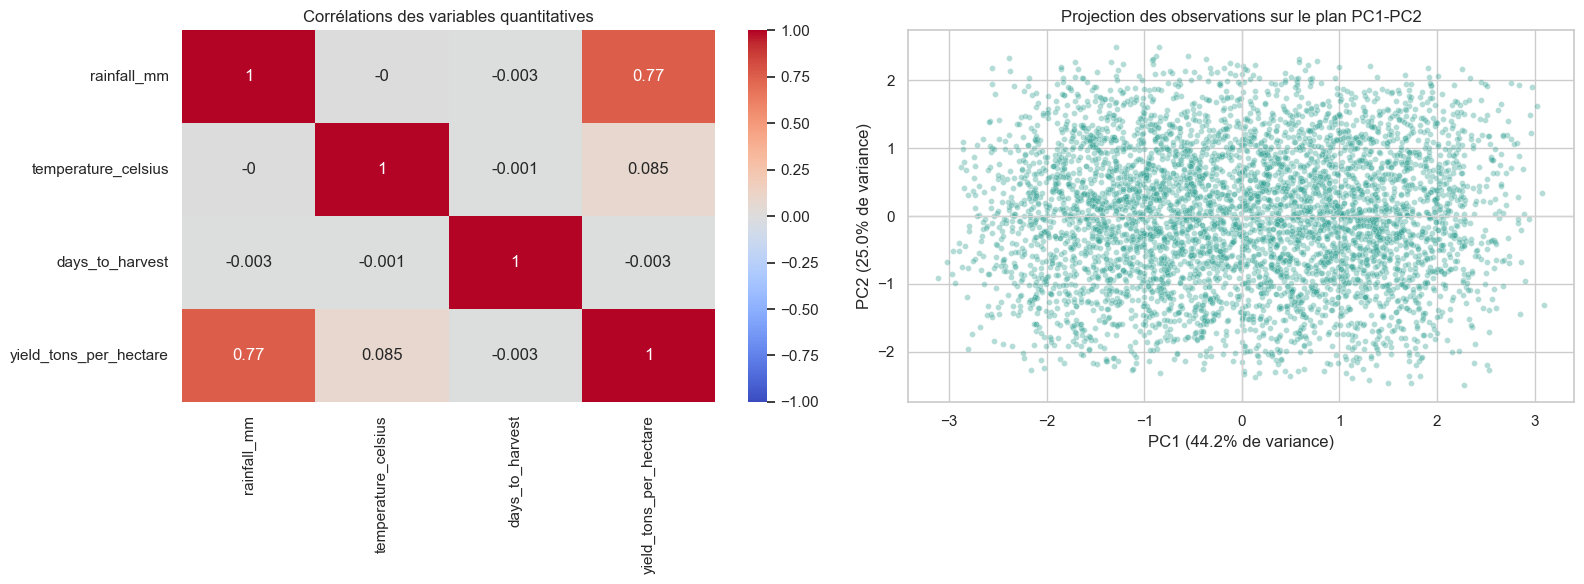

In [15]:
pca_input = agriculture_crop_yield_clean[pca_numeric_cols].copy()
pca_scaler = StandardScaler()
pca_scaled = pca_scaler.fit_transform(pca_input)

pca_model = PCA()
pca_features = pca_model.fit_transform(pca_scaled)

pca_scores = pd.DataFrame(
    pca_features,
    columns=[f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
)
pca_scores_sample = pca_scores.sample(n=min(5000, len(pca_scores)), random_state=SEED)

pca_correlation = pca_input.corr().round(3)
display(pca_correlation)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    pca_correlation,
    annot=True,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0],
)
axes[0].set_title('Corrélations des variables quantitatives')

sns.scatterplot(
    data=pca_scores_sample,
    x='PC1',
    y='PC2',
    alpha=0.35,
    s=18,
    color='#2a9d8f',
    ax=axes[1],
)
axes[1].set_title('Projection des observations sur le plan PC1-PC2')
axes[1].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} de variance)")
axes[1].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} de variance)")
axes[1].axhline(0, color='lightgray', linewidth=1)
axes[1].axvline(0, color='lightgray', linewidth=1)

plt.tight_layout()
plt.show()


,contribution_absolue_pc1
yield_tons_per_hectare,0.941
rainfall_mm,0.935
temperature_celsius,0.104
days_to_harvest,0.007


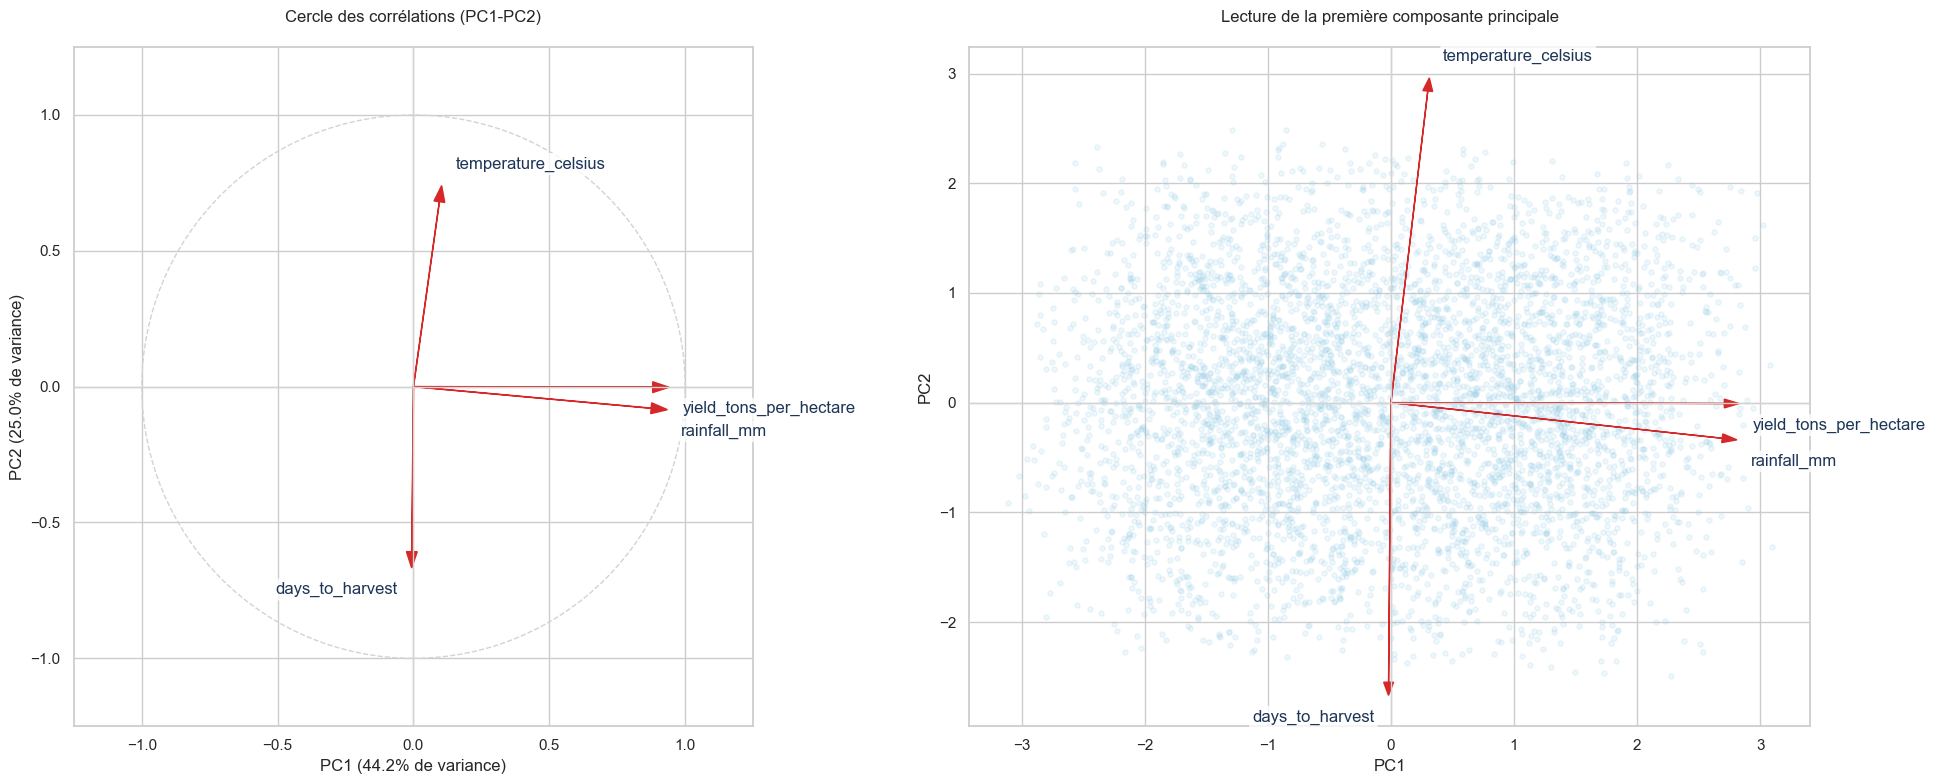

In [16]:
pca_loadings = pd.DataFrame(
    pca_model.components_.T,
    index=pca_numeric_cols,
    columns=[f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
)
pca_variable_coords = pd.DataFrame(
    pca_model.components_.T * np.sqrt(pca_model.explained_variance_),
    index=pca_numeric_cols,
    columns=[f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
)

pc1_contributions = (
    pca_variable_coords['PC1']
    .abs()
    .sort_values(ascending=False)
    .rename('contribution_absolue_pc1')
    .to_frame()
)
display(pc1_contributions.round(3))

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

correlation_circle = plt.Circle((0, 0), 1, color='lightgray', fill=False, linestyle='--')
axes[0].add_patch(correlation_circle)

for variable in pca_numeric_cols:
    x = pca_variable_coords.loc[variable, 'PC1']
    y = pca_variable_coords.loc[variable, 'PC2']
    axes[0].arrow(0, 0, x, y, color='#d62828', head_width=0.04, length_includes_head=True)
    axes[0].annotate(
        variable,
        xy=(x, y),
        xytext=(10 if x >= 0 else -10, 10 if y >= 0 else -10),
        textcoords='offset points',
        color='#1d3557',
        ha='left' if x >= 0 else 'right',
        va='bottom' if y >= 0 else 'top',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
    )

axes[0].set_title('Cercle des corrélations (PC1-PC2)', pad=18)
axes[0].set_xlabel(f"PC1 ({pca_model.explained_variance_ratio_[0]:.1%} de variance)")
axes[0].set_ylabel(f"PC2 ({pca_model.explained_variance_ratio_[1]:.1%} de variance)")
axes[0].set_xlim(-1.25, 1.25)
axes[0].set_ylim(-1.25, 1.25)
axes[0].set_aspect('equal', 'box')
axes[0].axhline(0, color='lightgray', linewidth=1)
axes[0].axvline(0, color='lightgray', linewidth=1)

axes[1].scatter(
    pca_scores_sample['PC1'],
    pca_scores_sample['PC2'],
    alpha=0.15,
    s=14,
    color='#8ecae6',
)

for variable in pca_numeric_cols:
    x = pca_loadings.loc[variable, 'PC1'] * 4
    y = pca_loadings.loc[variable, 'PC2'] * 4
    axes[1].arrow(0, 0, x, y, color='#d62828', head_width=0.08, length_includes_head=True)
    axes[1].annotate(
        variable,
        xy=(x, y),
        xytext=(10 if x >= 0 else -10, 10 if y >= 0 else -10),
        textcoords='offset points',
        color='#1d3557',
        ha='left' if x >= 0 else 'right',
        va='bottom' if y >= 0 else 'top',
        bbox=dict(boxstyle='round,pad=0.2', facecolor='white', edgecolor='none', alpha=0.8),
    )

axes[1].set_title('Lecture de la première composante principale', pad=18)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].axhline(0, color='lightgray', linewidth=1)
axes[1].axvline(0, color='lightgray', linewidth=1)

plt.tight_layout()
plt.show()


,composante,variance_expliquee,variance_cumulee
0,PC1,0.4423,0.4423
1,PC2,0.2501,0.6924
2,PC3,0.2499,0.9423
3,PC4,0.0577,1.0000


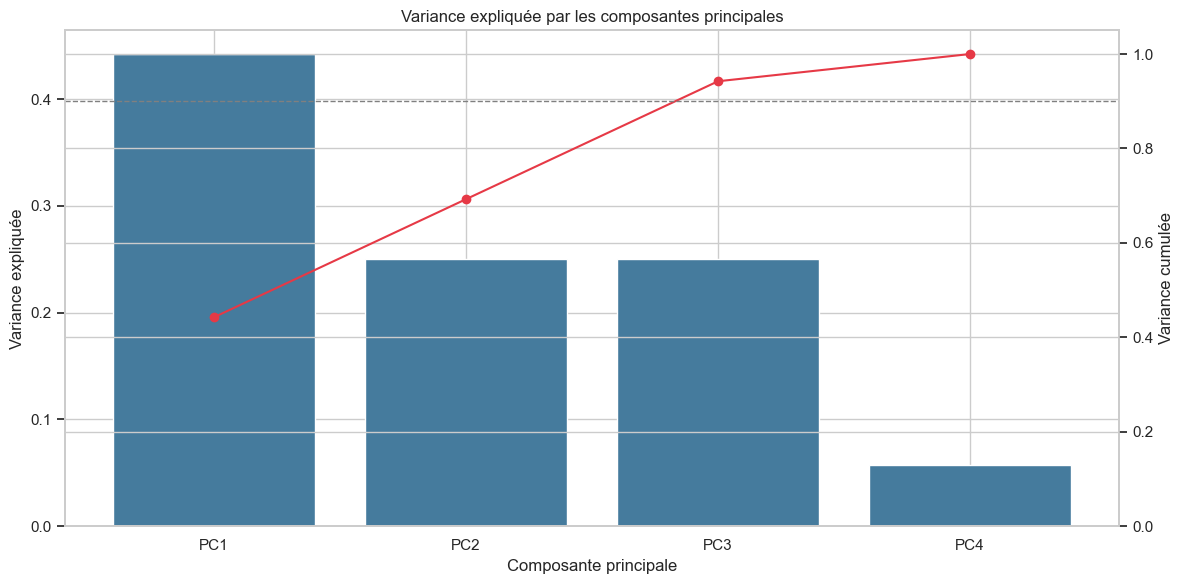

Une valeur raisonnable pour la dimension intrinsèque est 3 composantes, car elles conservent 94.2% de la variance totale.
Nombre de composantes conservées : 3
Shape initiale : (999769, 4)
Shape réduite : (999769, 3)
Variance cumulée conservée : 94.2%


,composante,variance_expliquee
0,PC1,0.4423
1,PC2,0.2501
2,PC3,0.2499


,PC1,PC2,PC3
0,1.731895,-0.547980,0.426069
1,2.705212,-2.033403,0.033210
2,-2.532823,0.331218,0.357724
3,1.835090,-2.324983,0.076524
4,1.614697,0.218266,0.491012


In [17]:
pca_variance = pd.DataFrame(
    {
        'composante': [f'PC{i + 1}' for i in range(len(pca_numeric_cols))],
        'variance_expliquee': pca_model.explained_variance_ratio_,
        'variance_cumulee': np.cumsum(pca_model.explained_variance_ratio_),
    }
).round(4)
display(pca_variance)

intrinsic_dimension = int(np.argmax(pca_variance['variance_cumulee'].to_numpy() >= 0.90) + 1)
positions = np.arange(len(pca_variance))

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.bar(positions, pca_variance['variance_expliquee'], color='#457b9d')
ax1.set_xlabel('Composante principale')
ax1.set_ylabel('Variance expliquée')
ax1.set_xticks(positions)
ax1.set_xticklabels(pca_variance['composante'])

ax2 = ax1.twinx()
ax2.plot(positions, pca_variance['variance_cumulee'], marker='o', color='#e63946')
ax2.axhline(0.90, linestyle='--', color='gray', linewidth=1)
ax2.set_ylabel('Variance cumulée')
ax2.set_ylim(0, 1.05)

plt.title('Variance expliquée par les composantes principales')
plt.tight_layout()
plt.show()

print(
    f"Une valeur raisonnable pour la dimension intrinsèque est {intrinsic_dimension} composantes, "
    f"car elles conservent {pca_variance.loc[intrinsic_dimension - 1, 'variance_cumulee']:.1%} de la variance totale."
)

pca_n_components = intrinsic_dimension
pca_reducer = PCA(n_components=pca_n_components)
pca_reduced_features = pca_reducer.fit_transform(pca_scaled)

agriculture_crop_yield_pca = pd.DataFrame(
    pca_reduced_features,
    columns=[f'PC{i + 1}' for i in range(pca_n_components)],
)

agriculture_crop_yield_pca_ready = pd.concat(
    [
        agriculture_crop_yield_clean.drop(columns=pca_numeric_cols).reset_index(drop=True),
        agriculture_crop_yield_pca,
    ],
    axis=1,
)

print(f'Nombre de composantes conservées : {pca_n_components}')
print(f'Shape initiale : {pca_input.shape}')
print(f'Shape réduite : {agriculture_crop_yield_pca.shape}')
print(f"Variance cumulée conservée : {pca_reducer.explained_variance_ratio_.sum():.1%}")

display(
    pd.DataFrame(
        {
            'composante': [f'PC{i + 1}' for i in range(pca_n_components)],
            'variance_expliquee': pca_reducer.explained_variance_ratio_,
        }
    ).round(4)
)
display(agriculture_crop_yield_pca.head())


## Finalisation de l'étape 1 : fusion et dataset consolidé

Le scénario de fusion est rappelé ici pour que ce notebook soit autonome.

- `yield.csv` sert de table de base, car il porte la cible de rendement avec une clé propre `Area + Item + Year`.
- `rainfall.csv`, `pesticides.csv` et `temp.csv` enrichissent cette base sur la clé `Area + Year`.
- `yield_df.csv` sert uniquement de fichier d'audit pour contrôler la cohérence du résultat.
- `crop_yield.csv` a été nettoyé et analysé plus haut, mais il n'existe pas de clé robuste `Area + Year` permettant une fusion directe propre avec ces fichiers sans fabriquer artificiellement la jointure.

Le dataset consolidé produit ici devient donc la source de vérité opérationnelle pour la suite du pipeline.


In [18]:
source_paths = {
    "yield.csv": YIELD_PATH,
    "rainfall.csv": RAINFALL_PATH,
    "pesticides.csv": PESTICIDES_PATH,
    "temp.csv": TEMP_PATH,
    "yield_df.csv": YIELD_DF_AUDIT_PATH,
}

missing_source_files = [name for name, path in source_paths.items() if not path.exists()]
if missing_source_files:
    raise FileNotFoundError(f"Fichiers introuvables : {missing_source_files}")

yield_source = pd.read_csv(YIELD_PATH)
rainfall_source = pd.read_csv(RAINFALL_PATH, na_values=[".."])
pesticides_source = pd.read_csv(PESTICIDES_PATH)
temp_source = pd.read_csv(TEMP_PATH)
yield_df_source = pd.read_csv(YIELD_DF_AUDIT_PATH)

source_overview = pd.DataFrame(
    [
        {
            "fichier": "yield.csv",
            "lignes": yield_source.shape[0],
            "colonnes": yield_source.shape[1],
            "nan_detectes": int(yield_source.isna().sum().sum()),
        },
        {
            "fichier": "rainfall.csv",
            "lignes": rainfall_source.shape[0],
            "colonnes": rainfall_source.shape[1],
            "nan_detectes": int(rainfall_source.isna().sum().sum()),
        },
        {
            "fichier": "pesticides.csv",
            "lignes": pesticides_source.shape[0],
            "colonnes": pesticides_source.shape[1],
            "nan_detectes": int(pesticides_source.isna().sum().sum()),
        },
        {
            "fichier": "temp.csv",
            "lignes": temp_source.shape[0],
            "colonnes": temp_source.shape[1],
            "nan_detectes": int(temp_source.isna().sum().sum()),
        },
        {
            "fichier": "yield_df.csv",
            "lignes": yield_df_source.shape[0],
            "colonnes": yield_df_source.shape[1],
            "nan_detectes": int(yield_df_source.isna().sum().sum()),
        },
    ]
)

display(source_overview)


,fichier,lignes,colonnes,nan_detectes
0,yield.csv,56717,12,0
1,rainfall.csv,6727,3,780
2,pesticides.csv,4349,7,0
3,temp.csv,71311,3,2547
4,yield_df.csv,28242,8,0


### Nettoyage et harmonisation retenus

Les choix appliqués ici restent strictement dans le périmètre de l'étape 1 :

- harmoniser les noms de colonnes autour de `area`, `crop` et `year` ;
- convertir les mesures en numérique et normaliser la cible de rendement en `t/ha` ;
- agréger `temp.csv` par moyenne sur `Area + Year`, car ce fichier n'est pas exploitable tel quel à cause des doublons ;
- conserver un dataset final sans colonnes redondantes : la cible finale est `target_yield_t_ha`, les variables explicatives sont limitées aux facteurs climatiques, d'intrants et de contexte.


In [19]:
yield_clean = (
    yield_source.loc[:, ["Area", "Item", "Year", "Unit", "Value"]]
    .rename(
        columns={
            "Area": "area",
            "Item": "crop",
            "Year": "year",
            "Unit": "yield_unit",
            "Value": "yield_hg_ha",
        }
    )
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        crop=lambda df: df["crop"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        yield_hg_ha=lambda df: pd.to_numeric(df["yield_hg_ha"], errors="coerce"),
    )
)

yield_units = sorted(yield_clean["yield_unit"].dropna().astype(str).unique().tolist())
print(f"Unités observées dans yield.csv : {yield_units}")

yield_clean["target_yield_t_ha"] = yield_clean["yield_hg_ha"] / 10000
yield_clean = yield_clean.drop(columns=["yield_unit", "yield_hg_ha"])

rainfall_clean = (
    rainfall_source.rename(columns={" Area": "Area"})
    .loc[:, ["Area", "Year", "average_rain_fall_mm_per_year"]]
    .rename(columns={"Area": "area", "Year": "year"})
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        average_rain_fall_mm_per_year=lambda df: pd.to_numeric(
            df["average_rain_fall_mm_per_year"], errors="coerce"
        ),
    )
)

pesticides_clean = (
    pesticides_source.loc[:, ["Area", "Year", "Value"]]
    .rename(columns={"Area": "area", "Year": "year", "Value": "pesticides_tonnes"})
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        pesticides_tonnes=lambda df: pd.to_numeric(df["pesticides_tonnes"], errors="coerce"),
    )
)

temp_clean = (
    temp_source.rename(columns={"country": "Area", "year": "Year"})
    .loc[:, ["Area", "Year", "avg_temp"]]
    .rename(columns={"Area": "area", "Year": "year"})
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        avg_temp=lambda df: pd.to_numeric(df["avg_temp"], errors="coerce"),
    )
    .groupby(["area", "year"], as_index=False)["avg_temp"].mean()
)

yield_df_audit_clean = (
    yield_df_source.loc[
        :,
        [
            "Area",
            "Item",
            "Year",
            "hg/ha_yield",
            "average_rain_fall_mm_per_year",
            "pesticides_tonnes",
            "avg_temp",
        ],
    ]
    .rename(
        columns={
            "Area": "area",
            "Item": "crop",
            "Year": "year",
            "hg/ha_yield": "yield_hg_ha",
        }
    )
    .assign(
        area=lambda df: df["area"].astype("string").str.strip(),
        crop=lambda df: df["crop"].astype("string").str.strip(),
        year=lambda df: pd.to_numeric(df["year"], errors="raise").astype(int),
        yield_hg_ha=lambda df: pd.to_numeric(df["yield_hg_ha"], errors="coerce"),
        average_rain_fall_mm_per_year=lambda df: pd.to_numeric(
            df["average_rain_fall_mm_per_year"], errors="coerce"
        ),
        pesticides_tonnes=lambda df: pd.to_numeric(df["pesticides_tonnes"], errors="coerce"),
        avg_temp=lambda df: pd.to_numeric(df["avg_temp"], errors="coerce"),
    )
)
yield_df_audit_clean["target_yield_t_ha"] = yield_df_audit_clean["yield_hg_ha"] / 10000

source_quality = pd.DataFrame(
    [
        {
            "table": "yield_clean",
            "clé": "area + crop + year",
            "doublons_sur_cle": int(yield_clean.duplicated(subset=["area", "crop", "year"]).sum()),
            "nan_totaux": int(yield_clean.isna().sum().sum()),
        },
        {
            "table": "rainfall_clean",
            "clé": "area + year",
            "doublons_sur_cle": int(rainfall_clean.duplicated(subset=["area", "year"]).sum()),
            "nan_totaux": int(rainfall_clean.isna().sum().sum()),
        },
        {
            "table": "pesticides_clean",
            "clé": "area + year",
            "doublons_sur_cle": int(pesticides_clean.duplicated(subset=["area", "year"]).sum()),
            "nan_totaux": int(pesticides_clean.isna().sum().sum()),
        },
        {
            "table": "temp_clean",
            "clé": "area + year",
            "doublons_sur_cle": int(temp_clean.duplicated(subset=["area", "year"]).sum()),
            "nan_totaux": int(temp_clean.isna().sum().sum()),
        },
        {
            "table": "yield_df_audit_clean",
            "clé": "area + crop + year",
            "doublons_sur_cle": int(yield_df_audit_clean.duplicated(subset=["area", "crop", "year"]).sum()),
            "nan_totaux": int(yield_df_audit_clean.isna().sum().sum()),
        },
    ]
)

display(source_quality)

assert yield_clean.duplicated(subset=["area", "crop", "year"]).sum() == 0
assert rainfall_clean.duplicated(subset=["area", "year"]).sum() == 0
assert pesticides_clean.duplicated(subset=["area", "year"]).sum() == 0
assert temp_clean.duplicated(subset=["area", "year"]).sum() == 0


Unités observées dans yield.csv : ['hg/ha']


,table,clé,doublons_sur_cle,nan_totaux
0,yield_clean,area + crop + year,0,0
1,rainfall_clean,area + year,0,780
2,pesticides_clean,area + year,0,0
3,temp_clean,area + year,0,1035
4,yield_df_audit_clean,area + crop + year,15112,0


In [20]:
dataset_consolide = (
    yield_clean.merge(rainfall_clean, on=["area", "year"], how="left", validate="m:1")
    .merge(pesticides_clean, on=["area", "year"], how="left", validate="m:1")
    .merge(temp_clean, on=["area", "year"], how="left", validate="m:1")
    .loc[
        :,
        [
            "area",
            "crop",
            "year",
            "target_yield_t_ha",
            "average_rain_fall_mm_per_year",
            "pesticides_tonnes",
            "avg_temp",
        ],
    ]
    .sort_values(["area", "crop", "year"])
    .reset_index(drop=True)
)

consolidation_summary = pd.DataFrame(
    {
        "indicateur": [
            "Nombre de lignes",
            "Nombre de colonnes",
            "Lignes totalement renseignées",
            "Part des lignes totalement renseignées (%)",
        ],
        "valeur": [
            int(dataset_consolide.shape[0]),
            int(dataset_consolide.shape[1]),
            int(dataset_consolide.notna().all(axis=1).sum()),
            round(dataset_consolide.notna().all(axis=1).mean() * 100, 2),
        ],
    }
)

missing_summary = (
    dataset_consolide.isna()
    .sum()
    .rename("nb_nan")
    .reset_index()
    .rename(columns={"index": "variable"})
)
missing_summary["part_nan_pct"] = (
    missing_summary["nb_nan"] / len(dataset_consolide) * 100
).round(2)

display(consolidation_summary)
display(missing_summary)
display(dataset_consolide.head())

DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
dataset_consolide.to_csv(DATASET_PATH, index=False)
print(f"Dataset consolidé sauvegardé : {DATASET_PATH.resolve()}")


,indicateur,valeur
0,Nombre de lignes,56717.00
1,Nombre de colonnes,7.00
2,Lignes totalement renseignées,13130.00
3,Part des lignes totalement renseignées (%),23.15


,variable,nb_nan,part_nan_pct
0,area,0,0.00
1,crop,0,0.00
2,year,0,0.00
3,target_yield_t_ha,0,0.00
4,average_rain_fall_mm_per_year,31332,55.24
5,pesticides_tonnes,32564,57.41
6,avg_temp,24507,43.21


,area,crop,year,target_yield_t_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Afghanistan,Maize,1961,1.4000,NaN,NaN,14.23
1,Afghanistan,Maize,1962,1.4000,NaN,NaN,14.10
2,Afghanistan,Maize,1963,1.4260,NaN,NaN,15.01
3,Afghanistan,Maize,1964,1.4257,NaN,NaN,13.73
4,Afghanistan,Maize,1965,1.4400,NaN,NaN,13.90


Dataset consolidé sauvegardé : /Users/steph/Code/Python/Jupyter/OCR_Projet12/data/dataset_consolide.csv


### Contrôle d'audit avec `yield_df.csv`

Ce contrôle ne sert pas à construire la table finale. Il vérifie simplement que le scénario de fusion reproduit bien la logique d'un fichier déjà enrichi du dossier.


In [21]:
yield_df_audit_unique = (
    yield_df_audit_clean.groupby(["area", "crop", "year"], as_index=False)[
        [
            "target_yield_t_ha",
            "average_rain_fall_mm_per_year",
            "pesticides_tonnes",
            "avg_temp",
        ]
    ].mean()
)

audit_overlap = dataset_consolide.merge(
    yield_df_audit_unique,
    on=["area", "crop", "year"],
    how="inner",
    suffixes=("_built", "_audit"),
)

audit_summary = pd.DataFrame(
    [
        {
            "controle": "Clés communes sur area + crop + year",
            "valeur": int(audit_overlap.shape[0]),
        },
        {
            "controle": "Écart absolu moyen sur la cible (t/ha)",
            "valeur": audit_overlap["target_yield_t_ha_built"]
            .sub(audit_overlap["target_yield_t_ha_audit"])
            .abs()
            .mean(),
        },
        {
            "controle": "Écart absolu moyen sur la pluie",
            "valeur": audit_overlap["average_rain_fall_mm_per_year_built"]
            .sub(audit_overlap["average_rain_fall_mm_per_year_audit"])
            .abs()
            .mean(),
        },
        {
            "controle": "Écart absolu moyen sur les pesticides",
            "valeur": audit_overlap["pesticides_tonnes_built"]
            .sub(audit_overlap["pesticides_tonnes_audit"])
            .abs()
            .mean(),
        },
        {
            "controle": "Écart absolu moyen sur la température",
            "valeur": audit_overlap["avg_temp_built"].sub(audit_overlap["avg_temp_audit"]).abs().mean(),
        },
    ]
)

display(audit_summary.round(4))


,controle,valeur
0,Clés communes sur area + crop + year,13130.0
1,Écart absolu moyen sur la cible (t/ha),0.0
2,Écart absolu moyen sur la pluie,0.0
3,Écart absolu moyen sur les pesticides,0.0
4,Écart absolu moyen sur la température,0.0


## Vérification du chargement du dataset consolidé

Cette cellule relit le CSV consolidé créé juste au-dessus. Elle sert de point d'entrée stable pour toute la partie modélisation.


In [22]:
if DATASET_PATH.exists():
    model_data = pd.read_csv(DATASET_PATH)
    print(f"Dataset chargé : {model_data.shape[0]:,} lignes x {model_data.shape[1]} colonnes")
    display(model_data.head())
else:
    model_data = None
    print("Dataset consolidé introuvable. Finaliser l'étape 1 puis mettre à jour DATASET_PATH.")


Dataset chargé : 56,717 lignes x 7 colonnes


,area,crop,year,target_yield_t_ha,average_rain_fall_mm_per_year,pesticides_tonnes,avg_temp
0,Afghanistan,Maize,1961,1.4000,NaN,NaN,14.23
1,Afghanistan,Maize,1962,1.4000,NaN,NaN,14.10
2,Afghanistan,Maize,1963,1.4260,NaN,NaN,15.01
3,Afghanistan,Maize,1964,1.4257,NaN,NaN,13.73
4,Afghanistan,Maize,1965,1.4400,NaN,NaN,13.90


## Cible et variables explicatives

La cible métier est fixée explicitement dans ce notebook : **le rendement attendu par hectare**, stocké sous le nom `target_yield_t_ha` dans le dataset consolidé.


In [23]:
TARGET_COL = "target_yield_t_ha"

if model_data is not None:
    if TARGET_COL not in model_data.columns:
        raise KeyError(
            f"La colonne cible attendue `{TARGET_COL}` est absente du dataset consolidé."
        )

    target_col = TARGET_COL
    feature_cols = [col for col in model_data.columns if col != target_col]
    print(f"Cible métier retenue : {target_col}")
    print(f"Variables explicatives disponibles : {feature_cols}")
else:
    target_col = TARGET_COL
    feature_cols = []
    print(
        "Pas de dataset chargé. La cible métier reste fixée à `target_yield_t_ha`, "
        "mais elle ne peut pas encore être lue dans les données."
    )


Cible métier retenue : target_yield_t_ha
Variables explicatives disponibles : ['area', 'crop', 'year', 'average_rain_fall_mm_per_year', 'pesticides_tonnes', 'avg_temp']


## Séparation train / test et typologie des variables

L'idée ici est de préparer les bases du pipeline : détecter les variables numériques et catégorielles, puis effectuer un premier split reproductible.


In [24]:
if model_data is not None and target_col is not None:
    X = model_data[feature_cols].copy()
    y = model_data[target_col].copy()

    numeric_features = X.select_dtypes(include=np.number).columns.tolist()
    categorical_features = [col for col in X.columns if col not in numeric_features]

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=SEED,
    )

    print(f"Train : {X_train.shape}")
    print(f"Test : {X_test.shape}")
    print(f"Variables numériques : {len(numeric_features)}")
    print(f"Variables catégorielles : {len(categorical_features)}")
else:
    X = y = X_train = X_test = y_train = y_test = None
    numeric_features = []
    categorical_features = []
    print("Split non exécuté : dataset consolidé ou cible manquants.")


Train : (45373, 6)
Test : (11344, 6)
Variables numériques : 4
Variables catégorielles : 2


## Pipeline de preprocessing

Cette partie prépare un pipeline scikit-learn réutilisable pour la modélisation. Le schéma proposé pourra être raffiné lorsque la structure du dataset consolidé sera stabilisée.


In [25]:
if feature_cols:
    numeric_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_transformer = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("encoder", OneHotEncoder(handle_unknown="ignore")),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )

    candidate_models = {
        "dummy": DummyRegressor(strategy="mean"),
        "linear_regression": LinearRegression(),
        "ridge": Ridge(random_state=SEED),
        "random_forest": RandomForestRegressor(random_state=SEED, n_estimators=200),
        "gradient_boosting": GradientBoostingRegressor(random_state=SEED),
    }

    print("Preprocessor et modèles candidats initialisés.")
    print(list(candidate_models.keys()))
else:
    preprocessor = None
    candidate_models = {}
    print("Pipeline non initialisé : variables explicatives indisponibles.")


Preprocessor et modèles candidats initialisés.
['dummy', 'linear_regression', 'ridge', 'random_forest', 'gradient_boosting']


## Évaluation, optimisation et MLflow

La suite du notebook devra contenir les blocs suivants :

- évaluation de plusieurs modèles sur des métriques homogènes ;
- optimisation des hyperparamètres ;
- suivi des runs MLflow ;
- sauvegarde du meilleur modèle.

Le dataset consolidé est désormais figé. La suite du notebook peut donc se concentrer sur l'entraînement et la comparaison des modèles.


In [ ]:
# TODO étape 2
# 1. Construire une boucle d'entraînement et de scoring pour les modèles candidats.
# 2. Ajouter une stratégie d'optimisation (GridSearchCV ou RandomizedSearchCV).
# 3. Comparer les modèles sur des métriques homogènes (MAE, RMSE, R2).
# 4. Intégrer MLflow si disponible dans l'environnement.
# 5. Sauvegarder le meilleur pipeline entraîné dans ARTIFACTS_DIR.

Étape 1 finalisée dans ce notebook. La suite peut passer à la modélisation proprement dite.
